In [6]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from pathlib import Path
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [8]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [9]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [10]:
dye = ["Nile Red"]

In [11]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [12]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

In [13]:
S_F.wavelength_to_energy(result.x[1])

617.6471332311454

In [14]:
denom = np.trapz(fitted_spectrum, wavelength)
wavelength_mean = np.trapz(fitted_spectrum * wavelength, wavelength) / denom
print(wavelength_mean)

651.910522254


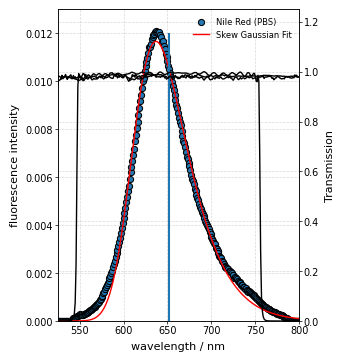

In [18]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=wavelength, y=dye_spectrum.T, ylabel='fluorescence intensity', xlabel='wavelength / nm', 
                           label='Nile Red (PBS)', facecolor=None)
axs = plotter.line_plot(axs, x=wavelength, y=fitted_spectrum, ylabel='fluorescence intensity', xlabel='wavelength / nm', color='red',
                       label='Skew Gaussian Fit')

ax2 = axs.twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])
axs.vlines(ymin=0, ymax=0.012, x=wavelength_mean)

axs.set_xlim([525, 800])
axs.set_ylim([0, 0.013])
axs.legend(loc='best', frameon=False, fontsize=6)
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.show()
#plt.savefig(os.path.join(folder, 'Fit_Fluo_Spectrum.svg'), dpi=600, format='svg')

In [15]:
svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680])
len(svalues)

13

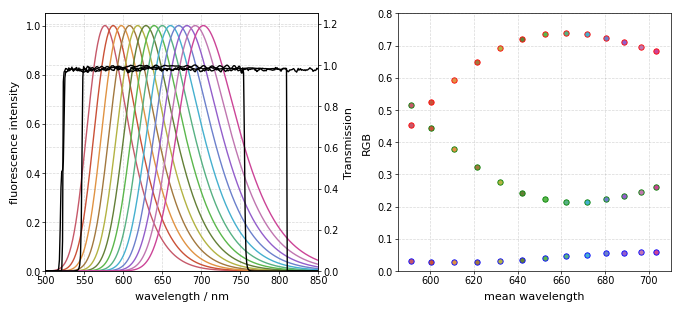

In [38]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1,1])
colours = ["#c6596a",
"#ca5137",
"#e09343",
"#a2783e",
"#b3b343",
"#637f37",
"#5bb74c",
"#57b183",
"#45b0cf",
"#6c80cc",
"#935ecb",
"#c076b0",
"#cc4497"]

svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680])
for i, s in enumerate(svalues):
    spectrum = NR_F.generate_nile_red_spectrum(
                s, wavelength, normalize=True
            )
    spectrum_filtered = NR_F.apply_optical_filters(spectrum, filter_spectra)
    rgb = NR_F.calculate_rgb_from_spectrum(
            spectrum_filtered, wavelength, pixel_QYs
        )
    denom = np.trapz(spectrum_filtered, wavelength)
    wavelength_mean = np.trapz(spectrum_filtered * wavelength, wavelength) / denom

    axs[0] = plotter.line_plot(axs[0], x=wavelength, y=spectrum/np.max(spectrum), 
                               ylabel='fluorescence intensity', xlabel='wavelength / nm', color=colours[i],)

    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[0], facecolor=colours[i], xlabel='mean wavelength', edgecolor='red',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[1], facecolor=colours[i], xlabel='mean wavelength', edgecolor='green',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[2], facecolor=colours[i], xlabel='mean wavelength', edgecolor='blue',
                                 ylabel='RGB', linewidth=0.6, size=15)


ax2 = axs[0].twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])

axs[0].set_xlim([500, 850])
axs[0].set_ylim([0, 1.05])
axs[1].set_xlim([585, 710])
axs[1].set_ylim([0.0, 0.8])

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.savefig(os.path.join(folder, 'Example_Propagation_Figure.svg'), dpi=600, format='svg')

In [82]:
n_photons = {}
s = 1
n_photons["Nile Red"] = np.full(s, 2000)
# n_photons["CF680"] = np.full(s, 5000)

dyes = np.zeros([2, len(wavelength)])

image_size = 16
pixel_size = 69
x0y0 = {}
max = pixel_size * image_size

dyes = list(n_photons.keys())
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, pixel_QYs)
)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

center = max / 2
scaling = 1000

image_size = pixel_size * np.array(camera_parameters["gain"].shape)
x0 = np.full(s, (image_size[0]) / 2) + np.random.normal(scale=1 * pixel_size, size=s)
y0 = np.full(s, (image_size[1]) / 2) + np.random.normal(scale=1 * pixel_size, size=s)

for dye in n_photons:
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[x0, y0]]).T

bayer_image_AF647 = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    background_photons=5.0,
    NA=1.49,
    pixel_size=pixel_size,
    return_normal_image=True,
    smoothing_function=smoothing_function
)

In [83]:
NRimage = bayer_image_AF647[0]

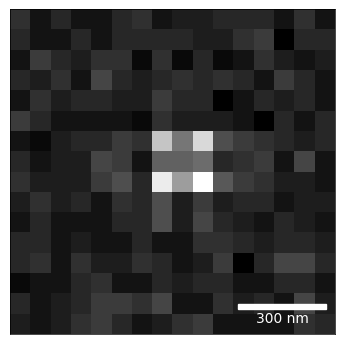

In [92]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, data=NRimage, cbar='off', scalebarsize=300, vmin=np.percentile(NRimage, 0.01),
                         vmax=np.percentile(NRimage, 99.99), scalebarlabel='300 nm')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251023/fig/multicolour/Nile_Red/'
plt.savefig(os.path.join(folder, 'Nile_Red_Example.svg'), dpi=600, format='svg')
plt.show()

In [29]:
# from https://www.sciencedirect.com/science/article/pii/0003269787901576
dielectric_constant = np.array([80, 64, 58, 44 ,37, 27, 34, 44, 24, 18, 11, 18, 38, 37, 21])
emission = np.array([665, 657, 655, 653, 652, 644, 642, 635, 635, 633, 633, 628, 627, 625, 615])

In [30]:
eV = S_F.wavelength_to_energy(emission)

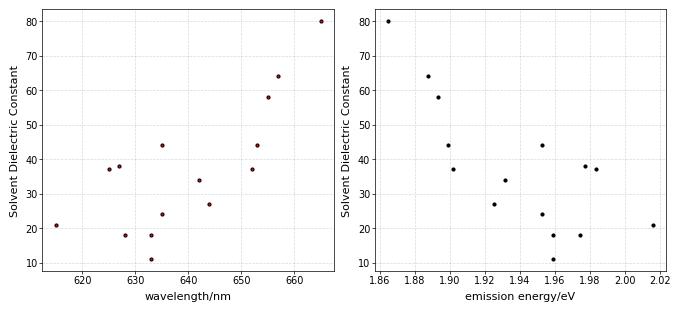

In [31]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

axs[1] = plotter.scatter_plot(axs[1], eV, dielectric_constant,
                          xaxislabel='emission energy/eV',
                          yaxislabel='Solvent Dielectric Constant')

axs[0] = plotter.scatter_plot(axs[0], emission, dielectric_constant, facecolor='red',
                          xaxislabel='wavelength/nm', yaxislabel='Solvent Dielectric Constant')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.savefig(os.path.join(folder, 'Nile_Red_Vs_Solvent.svg'), dpi=600, format='svg')

In [32]:
from src import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [17]:
# Photon range updated to match real Nile Red / NR4A exemplar data (NR/Localisations.h5,
# NR4A/Localisations.h5, and the SAureus NR4A titration): the bulk of real, QC'd
# localisations fall between ~100 and ~30,000 photons (1st-99th percentile across
# datasets), vs. the previous 500-20000 range.
n_photon_space = np.logspace(np.log10(100), np.log10(10000), 25)

# Background likewise updated: real per-localisation background_photons (bg_B+bg_G+bg_R)
# medians ~35-45 for Nile Red, ~45-70 for NR4A/SAureus -- swept as three representative
# levels (previously a single, unrealistically low flat 5.0) rather than one flat value.
background_levels = [20.0, 45.0, 70.0]  # NR-like low / typical / NR4A-SAureus-like high

save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting"

for background_photons in background_levels:
    NR_F.simulate_wavelength_precision(
          save_folder=save_folder,
          wavelength_range=(560, 680),
          wavelength_step=5,
          photon_counts=n_photon_space,
          filter_names=filters,
          n_bootstrap=10000,
          image_size = 16,
          background_photons=background_photons,
          camera_parameters=camera_parameters,
          starting_flag=f"bg{int(background_photons)}_",
          verbose=False,
          use_tqdm=False,
      )

INFO:IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:IOFunctions:  Read 20,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:IOFunctions:  Read 30,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:IOFunctions:  Read 40,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:IOFunctions:  Read 50,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
INFO:IOFunctions:  Read 60,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5


...

INFO:IOFunctions:Sorting appended HDF5 file by frame: bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:IOFunctions:  Read 210,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:IOFunctions:  Read 220,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:IOFunctions:  Read 230,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:IOFunctions:  Read 240,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5


INFO:IOFunctions:Sorting appended HDF5 file by frame: bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:IOFunctions:  Read 250,000 total localizations
INFO:IOFunctions:  Sorted by frame (range: 0-9999)
INFO:IOFunctions:  Rewritten sorted data to bg70_wl680_LM_method_simulated_NileRed_680nm_rawresults.h5
INFO:simulation.multicolour:
Completed analysis of 25 photon flux values    Total time: 20.825 min
INFO:simulation.multicolour:Simulation completed for strategy standard_data


In [18]:
# Read back from the same folder/naming scheme the sweep above just wrote (previously this
# pointed at a stale, unrelated cached folder from an older run).
files_650 = H_F.file_search(save_folder, '.h5', 'wl585')
files_650_truth = H_F.file_search(save_folder, '.csv', 'wl585')

In [19]:
# One summary CSV per background level (starting_flag=f"bg{int(background_photons)}_"),
# all in the same save_folder -- load and concatenate, tagging each with its background level.
data_frames = []
for background_photons in background_levels:
    file = f"bg{int(background_photons)}_wavelength_precision_summary.csv"
    df_bg = pd.read_csv(os.path.join(save_folder, file))
    df_bg["background_photons"] = background_photons
    data_frames.append(df_bg)
data = pd.concat(data_frames, ignore_index=True)

In [20]:
true_wavelengths = np.unique(data['wavelength_true'].to_numpy())

In [21]:
true_wavelengths

array([560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620,
       625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680])

In [39]:
n_photons = 25

In [ ]:
cs = ["#db465d",
"#aa4c4c",
"#c95129",
"#e0916c",
"#dc9334",
"#936b2f",
"#bdaf4e",
"#717c33",
"#9ab832",
"#458631",
"#58bf4d",
"#6fbe77",
"#317b54",
"#52b28e",
"#43c4c6",
"#53a0d5",
"#5174c6",
"#7967dd",
"#aa93d6",
"#7952a2",
"#b047b7",
"#da7dd5",
"#9f4c79",
"#d6418d",
"#e284a4"]

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'

# One figure per background level (previously a single flat background=5.0 -- now
# repeated for each realistic background level in background_levels).
for background_photons in background_levels:
    data_bg = data[data['background_photons'] == background_photons]

    fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

    for wavelength in true_wavelengths:
        subset = data_bg[data_bg['wavelength_true'] == wavelength]
        for i in np.arange(len(subset)):
            axs[0] = plotter.scatter_plot(axs[0], wavelength, subset['wavelength_precision'].to_numpy()[i], edgecolor=None,
                                         facecolor=cs[i], yaxislabel='spectral estimation σ/nm',
                                         xaxislabel='mean nile red wavelength/nm')
            axs[1] = plotter.scatter_plot(axs[1], wavelength, subset['wavelength_bias'].to_numpy()[i], edgecolor=None,
                                         facecolor=cs[i], yaxislabel='spectral bias/nm',
                                         xaxislabel='mean nile red wavelength/nm', marker='v')

    axs[0].set_xlim([555, 625])
    axs[0].set_ylim([0.9*np.min(data_bg['wavelength_precision']), 1.2*np.max(data_bg['wavelength_precision'])])
    axs[0].set_yscale('log')

    axs[1].set_xlim([555, 625])
    axs[1].set_ylim([-1, 1.2*np.max((data_bg['wavelength_bias']))])

    fig.suptitle(f"background = {background_photons:.0f} photons/pixel", fontsize=9)
    plt.savefig(os.path.join(folder, f'Forward_Model_Validation_bg{int(background_photons)}.svg'), dpi=600, format='svg')
    plt.show()

In [42]:
data['n_photons']

0        410.280669
1        467.563638
2        532.567369
3        612.323160
4        707.979654
           ...     
320     7550.855442
321     8804.313135
322    10274.910313
323    11988.701315
324    13977.732358
Name: n_photons, Length: 325, dtype: float64

## Does pixellating localisations before fitting reduce bias?

Real Nile Red/NR4A analysis (`NileRedFunctions.fit_wavelengths_pixelated`) spatially bins
many localisations and fits one wavelength per bin, rather than fitting every
localisation individually -- on the assumption that pooling improves things. That
assumption has never been checked against known ground truth. Here we simulate
`N_BOOTSTRAP_PT` independent localisations at a single known true wavelength, photon
level and background, then compare three ways of turning them into a wavelength
estimate:

- **(a) Individual** (`k=1`) -- fit each localisation's own wavelength independently
  (the existing per-bootstrap `wl_fit`, unbinned) -- current production behaviour.
- **(b) Pixellated/pooled** (`k>1`) -- group localisations into batches of `k`, sum their
  *raw* per-channel photon counts and background (mirroring what literally happens when
  multiple emitters land in the same render pixel, or get frame-linked) into one combined
  observation, then fit **once** per group.
- **(c) Equal-photon-budget control** -- a separate simulation at
  `n_photon = k * photon_level`, i.e. the same total photon budget as (b) achieved in one
  shot rather than pooled -- checked as a sanity check on the grouping code, and to see
  whether pooling many dim localisations is as good as one bright one.

`photon_level` sweeps `PHOTON_LEVELS_PT` (representative per-localisation photon counts
from the updated real-data range above); `k` sweeps `K_VALUES_PT` (realistic render-pixel
occupancy, matching the "~25 locs/pixel" figure already used for the real 50 nm
pixellated fit). Background is fixed at a representative `BACKGROUND_PT` and true
wavelength at `WL_TRUE_PT` to keep this exploratory grid a manageable size -- the sweep
above already covers the full wavelength/background range for the unbinned baseline.

In [ ]:
# Fresh wavelength_array/pixel_QYs/filter_spectra from setup_optical_system, rather than
# reusing the notebook's `wavelength` global -- the validation-figure cell above runs
# `for wavelength in true_wavelengths:`, which overwrites `wavelength` (originally the
# spectral wavelength grid) with a scalar. Distinct names here avoid that collision.
wavelength_array, pixel_QYs_pt, filter_spectra_pt = NR_F.setup_optical_system(filters)

pixel_pt_size = 69.0  # nm
NA_pt = 1.49
WL_TRUE_PT = 600.0     # representative true wavelength (location parameter) for this test
BACKGROUND_PT = 45.0   # representative background (median across real NR/NR4A datasets)
N_BOOTSTRAP_PT = 3000
PHOTON_LEVELS_PT = np.array([100.0, 300.0, 1000.0, 3000.0, 10000.0])  # per-localisation
K_VALUES_PT = [1, 5, 10, 25, 50]  # localisations pooled per "pixel" (k=1 -> individual)

pixellation_save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRed_PixellationTest"
os.makedirs(pixellation_save_folder, exist_ok=True)

spectrum_pt = NR_F.generate_nile_red_spectrum(WL_TRUE_PT, wavelength_array, normalize=True)

# fit_nile_red_wavelength returns the spectral centre of mass, which for a skewed
# spectrum is *not* equal to the location parameter WL_TRUE_PT -- compare bias against
# the true spectrum's own centre of mass (computed the same way), not WL_TRUE_PT itself.
WL_TRUE_COM_PT = NR_F.spectral_centre_of_mass(WL_TRUE_PT, wavelength_array)
print(f"WL_TRUE_PT (location parameter) = {WL_TRUE_PT:.2f} nm; "
      f"true spectral centre of mass = {WL_TRUE_COM_PT:.2f} nm")

In [ ]:
def get_localisation_batch(photon_level, flag_suffix):
    """Simulate N_BOOTSTRAP_PT independent localisations at WL_TRUE_PT/BACKGROUND_PT/
    photon_level (via the same test_fit_method/_add_nile_red_wavelength_fits machinery
    the main sweep above uses), returning the raw per-localisation fit DataFrame
    (A_R/A_G/A_B/s_x/s_y/photons/background_photons + individual wl_fit)."""
    config = Multicolour_Simulation_Functions.SimulationConfig(
        n_bootstrap=N_BOOTSTRAP_PT,
        background_photons=BACKGROUND_PT,
        NA=NA_pt,
        pixel_size=pixel_pt_size,
        cpu_fraction=0.9,
        save_raw_results=True,
        subtractx0y0=False,
        saverawimages=False,
    )
    flag = f"pixtest_{flag_suffix}_"
    dyestr = f"simulated_NileRed_{int(WL_TRUE_PT)}nm"

    MSF.test_fit_method(
        dye=dyestr,
        filters=filters,
        wavelength=wavelength_array,
        camera_parameters=camera_parameters,
        save_folder=pixellation_save_folder,
        n_photon_space=np.array([photon_level]),
        smoothing_function=smoothing_function,
        starting_flag=flag,
        config=config,
        single_dye_spectrum=spectrum_pt,
        nile_red_wavelength=WL_TRUE_PT,
    )

    raw_files = list(Path(pixellation_save_folder).glob(f"{flag}*rawresults.h5"))
    return IO.read_h5_database(str(raw_files[0]))

In [ ]:
def combine_group(df_group):
    """Combine a group of independent localisations into one observation by summing
    raw per-channel photon counts (mirrors what happens when multiple emitters land in
    the same render pixel, or get frame-linked) rather than averaging already-fit
    wavelengths."""
    photons_i = df_group['photons'].to_numpy()

    R_i = df_group['A_R'].to_numpy() * photons_i
    G_i = df_group['A_G'].to_numpy() * photons_i
    B_i = df_group['A_B'].to_numpy() * photons_i
    R_err_i = df_group['A_R_err'].to_numpy() * photons_i
    G_err_i = df_group['A_G_err'].to_numpy() * photons_i
    B_err_i = df_group['A_B_err'].to_numpy() * photons_i

    total_photons = float(photons_i.sum())
    background_photons_group = float(df_group['background_photons'].to_numpy().sum())

    rgb_sum = np.array([R_i.sum(), G_i.sum(), B_i.sum()])
    rgb_err_sum = np.sqrt(np.array([
        np.sum(R_err_i ** 2), np.sum(G_err_i ** 2), np.sum(B_err_i ** 2),
    ]))

    sx_i = df_group['s_x'].to_numpy() * pixel_pt_size
    sy_i = df_group['s_y'].to_numpy() * pixel_pt_size
    sx_err_i = df_group['s_x_err'].to_numpy() * pixel_pt_size
    sy_err_i = df_group['s_y_err'].to_numpy() * pixel_pt_size

    w = photons_i / total_photons  # photon-weighted mean for non-additive PSF widths
    sigma_x_group = float(np.sum(w * sx_i))
    sigma_y_group = float(np.sum(w * sy_i))
    sigma_x_err_group = float(np.sqrt(np.sum((w * sx_err_i) ** 2)))
    sigma_y_err_group = float(np.sqrt(np.sum((w * sy_err_i) ** 2)))

    return (
        rgb_sum, rgb_err_sum, sigma_x_group, sigma_y_group,
        sigma_x_err_group, sigma_y_err_group, total_photons, background_photons_group,
    )


def fit_pixelated_groups(df, k):
    """Split df into non-overlapping groups of size k, combine each group's raw photon
    counts (combine_group), and fit one wavelength per group."""
    n_groups = len(df) // k
    df_trim = df.iloc[: n_groups * k]
    wl_pixel = np.full(n_groups, np.nan)

    for g in range(n_groups):
        group = df_trim.iloc[g * k: (g + 1) * k]
        rgb_sum, rgb_err_sum, sx, sy, sx_err, sy_err, tot_photons, tot_bg = combine_group(group)
        if np.any(rgb_sum <= 0):
            continue
        wl, _ = NR_F.fit_nile_red_wavelength(
            observed_rgb=rgb_sum, observed_sigma_x=sx, observed_sigma_y=sy,
            rgb_errors=rgb_err_sum, sigma_x_error=sx_err, sigma_y_error=sy_err,
            filter_spectra=filter_spectra_pt, wavelength_array=wavelength_array,
            pixel_QYs=pixel_QYs_pt, NA=NA_pt, total_photons=tot_photons,
            background_photons=tot_bg,
        )
        wl_pixel[g] = wl

    return wl_pixel

In [ ]:
results_records = []

for photon_level in PHOTON_LEVELS_PT:
    df = get_localisation_batch(photon_level, flag_suffix=f"p{int(photon_level)}")

    for k in K_VALUES_PT:
        if k == 1:
            # (a) individual fits -- already computed per-localisation by
            # _add_nile_red_wavelength_fits inside test_fit_method, no pooling.
            wl_values = df['wl_fit'].to_numpy()
        else:
            # (b) pixellated/pooled fits.
            wl_values = fit_pixelated_groups(df, k)
        wl_values = wl_values[~np.isnan(wl_values)]
        if len(wl_values) == 0:
            continue
        results_records.append({
            'photon_level': photon_level,
            'k': k,
            'bias': np.mean(wl_values) - WL_TRUE_COM_PT,
            'precision': np.std(wl_values),
            'n_groups': len(wl_values),
        })

pixellation_results = pd.DataFrame(results_records)
pixellation_results.to_csv(os.path.join(pixellation_save_folder, 'pixellation_bias_precision.csv'), index=False)
pixellation_results

In [ ]:
# Sanity check (c): equal-photon-budget control. Fits n_photon = k*photon_level in one
# shot (no pooling) at the largest k, for the smallest and largest per-localisation photon
# levels -- should roughly match the pixellated (b) bias/precision at the same (photon_level, k),
# confirming the grouping/summing code above isn't silently wrong.
control_records = []
k_check = K_VALUES_PT[-1]
for photon_level in [PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]:
    df_control = get_localisation_batch(photon_level * k_check, flag_suffix=f"control_p{int(photon_level)}_k{k_check}")
    wl_control = df_control['wl_fit'].to_numpy()
    wl_control = wl_control[~np.isnan(wl_control)]
    control_records.append({
        'photon_level': photon_level, 'k': k_check,
        'equivalent_total_photons': photon_level * k_check,
        'bias': np.mean(wl_control) - WL_TRUE_COM_PT,
        'precision': np.std(wl_control),
    })

control_df = pd.DataFrame(control_records)
print("Equal-photon-budget control (c):")
print(control_df)
print("\nPixellated (b) at the same (photon_level, k) for comparison:")
print(pixellation_results[
    (pixellation_results['k'] == k_check)
    & (pixellation_results['photon_level'].isin([PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]))
])

In [ ]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])

k_colours = {1: '#d40000', 5: '#e0916c', 10: '#9ab832', 25: '#43c4c6', 50: '#5174c6'}

for k in K_VALUES_PT:
    subset = pixellation_results[pixellation_results['k'] == k].sort_values('photon_level')
    if len(subset) == 0:
        continue
    axs[0] = plotter.line_plot(
        axs[0], subset['photon_level'], subset['precision'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per localisation',
        ylabel='wavelength precision (σ) / nm',
    )
    axs[1] = plotter.line_plot(
        axs[1], subset['photon_level'], subset['bias'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per localisation',
        ylabel='wavelength bias / nm',
    )

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].axhline(0.0, color='k', lw=0.6, ls='--')
axs[1].legend(loc='best', fontsize=6)

fig.suptitle(
    f'Pixellation test: true wavelength={WL_TRUE_PT:.0f} nm, background={BACKGROUND_PT:.0f} photons/pixel',
    fontsize=8,
)

folder_pt = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.savefig(os.path.join(folder_pt, 'Pixellation_Bias_Precision.svg'), dpi=600, format='svg')
plt.show()